# 1. Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Aniket\OneDrive\Desktop\FCT\Australia\Flight_Data.csv")

In [3]:
df

,_id,Month,In_Out,Australian_City,International_City,Airline,Route,Port_Country,Port_Region,Service_Country,Service_Region,Stops,All_Flights,Max_Seats,Year,Month_num
0,1,Sep-03,I,Adelaide,Denpasar,Garuda Indonesia,DPS-ADL-MEL,Indonesia,SE Asia,Indonesia,SE Asia,0,13,3809,2003,9
1,2,Sep-03,I,Adelaide,Hong Kong,Cathay Pacific Airways,HKG-ADL-MEL,Hong Kong (SAR),NE Asia,Hong Kong (SAR),NE Asia,0,8,2008,2003,9
2,3,Sep-03,I,Adelaide,Kuala Lumpur,Malaysia Airlines,KUL-ADL,Malaysia,SE Asia,Malaysia,SE Asia,0,17,4726,2003,9
3,4,Sep-03,I,Adelaide,Singapore,Qantas Airways,SIN-DRW-ADL-MEL,Singapore,SE Asia,Singapore,SE Asia,1,4,908,2003,9
4,5,Sep-03,I,Adelaide,Singapore,Qantas Airways,SIN-DRW-ADL-SYD,Singapore,SE Asia,Singapore,SE Asia,1,9,2038,2003,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110050,110051,Sep-22,O,Sydney,Vancouver,Air Canada,SYD-YVR,Canada,N America,Canada,N America,0,33,10232,2022,9
110051,110052,Sep-22,O,Sydney,Vancouver,Qantas Airways,SYD-YVR,Canada,N America,Canada,N America,0,13,3068,2022,9
110052,110053,Sep-22,O,Sydney,Wellington,Air New Zealand,SYD-WLG,New Zealand,New Zealand,New Zealand,New Zealand,0,29,4686,2022,9
110053,110054,Sep-22,O,Sydney,Wellington,Qantas Airways,SYD-WLG,New Zealand,New Zealand,New Zealand,New Zealand,0,42,7308,2022,9


# 2. Basic Info

In [4]:
df.shape

(110055, 16)

In [5]:
df.columns

Index(['_id', 'Month', 'In_Out', 'Australian_City', 'International_City',
       'Airline', 'Route', 'Port_Country', 'Port_Region', 'Service_Country',
       'Service_Region', 'Stops', 'All_Flights', 'Max_Seats', 'Year',
       'Month_num'],
      dtype='object')

In [6]:
# Get some info about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110055 entries, 0 to 110054
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   _id                 110055 non-null  int64 
 1   Month               110055 non-null  object
 2   In_Out              110055 non-null  object
 3   Australian_City     110055 non-null  object
 4   International_City  110055 non-null  object
 5   Airline             110055 non-null  object
 6   Route               110055 non-null  object
 7   Port_Country        110055 non-null  object
 8   Port_Region         110055 non-null  object
 9   Service_Country     110055 non-null  object
 10  Service_Region      110055 non-null  object
 11  Stops               110055 non-null  int64 
 12  All_Flights         110055 non-null  int64 
 13  Max_Seats           110055 non-null  int64 
 14  Year                110055 non-null  int64 
 15  Month_num           110055 non-null  int64 
dtypes:

In [7]:
# Get statistical summary about the dataset

df.describe()

,_id,Stops,All_Flights,Max_Seats,Year,Month_num
count,110055.000000,110055.000000,110055.000000,110055.000000,110055.000000,110055.000000
mean,55028.000000,0.162464,24.775367,6610.760910,2012.726573,6.511762
std,31770.286275,0.388295,21.450937,6197.412623,4.817944,3.472462
min,1.000000,0.000000,0.000000,0.000000,2003.000000,1.000000
25%,27514.500000,0.000000,12.000000,2461.000000,2009.000000,3.000000
50%,55028.000000,0.000000,21.000000,4928.000000,2013.000000,6.000000
75%,82541.500000,0.000000,31.000000,9018.000000,2017.000000,9.000000
max,110055.000000,3.000000,178.000000,52596.000000,2022.000000,12.000000


# 3. Data Cleaning

In [8]:
# missing value

df.isnull().sum()

_id                   0
Month                 0
In_Out                0
Australian_City       0
International_City    0
Airline               0
Route                 0
Port_Country          0
Port_Region           0
Service_Country       0
Service_Region        0
Stops                 0
All_Flights           0
Max_Seats             0
Year                  0
Month_num             0
dtype: int64

In [9]:
# duplicates

df.duplicated().sum()

np.int64(0)

# 4. Flights Overview

## Total Flights

In [10]:
df['All_Flights'].sum()

np.int64(2726653)

## Flights by Airline

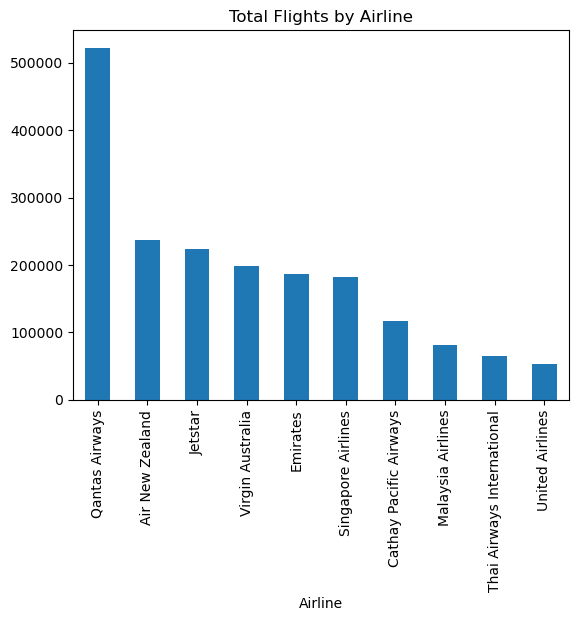

In [11]:
df.groupby('Airline')['All_Flights'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Total Flights by Airline')
plt.show()

## Domestic vs International

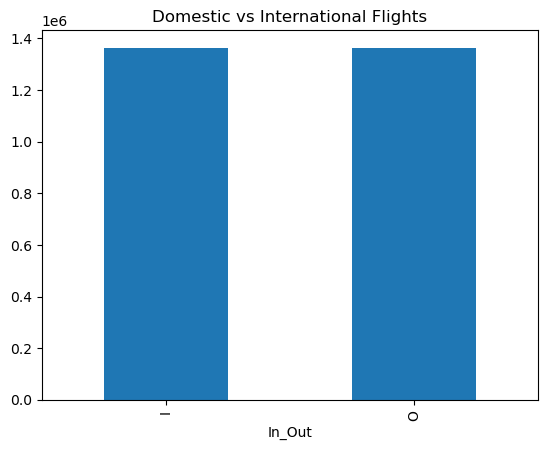

In [12]:
df.groupby('In_Out')['All_Flights'].sum().plot(kind='bar')
plt.title('Domestic vs International Flights')
plt.show()

# 5. City Analysis

## Top Australian Cities

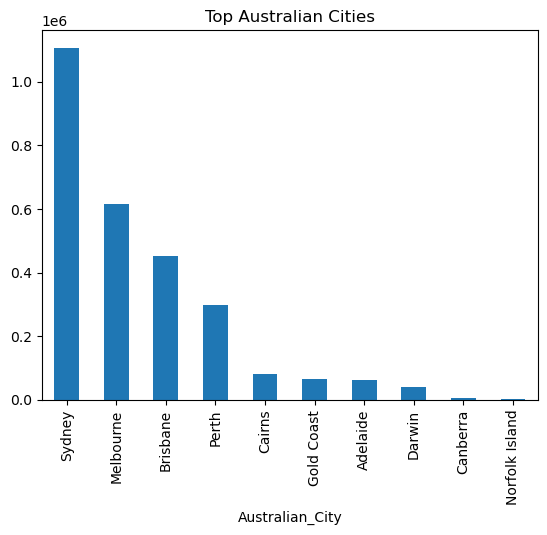

In [13]:
df.groupby('Australian_City')['All_Flights'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top Australian Cities')
plt.show()

## Top International Cities

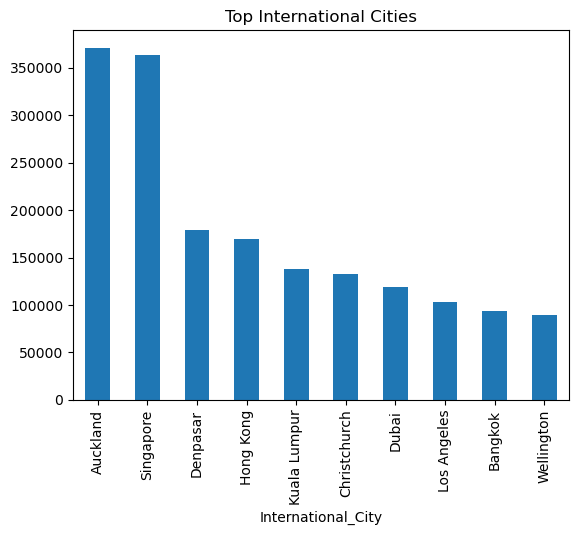

In [14]:
df.groupby('International_City')['All_Flights'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top International Cities')
plt.show()

# 6. Route Analysis

In [15]:
df.groupby('Route')['All_Flights'].sum().sort_values(ascending=False).head(10)

Route
SYD-AKL    61743
AKL-SYD    61710
PER-SIN    38325
SIN-PER    38223
AKL-MEL    36513
MEL-AKL    36338
DPS-PER    33576
PER-DPS    33491
AKL-BNE    30926
BNE-AKL    30864
Name: All_Flights, dtype: int64

# 7. Region Analysis

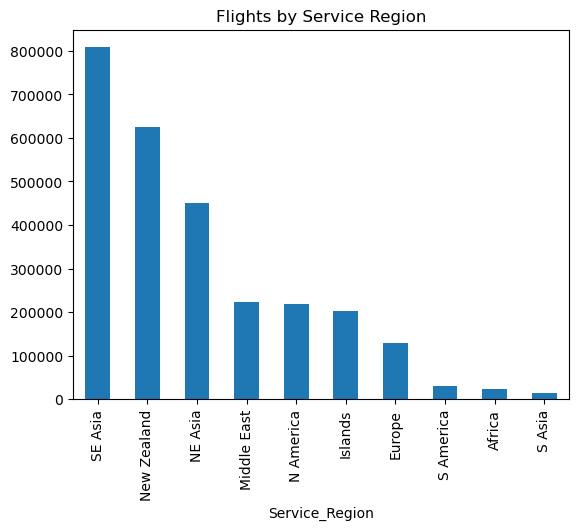

In [16]:
df.groupby('Service_Region')['All_Flights'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Flights by Service Region')
plt.show()

# 8. Stops Analysis

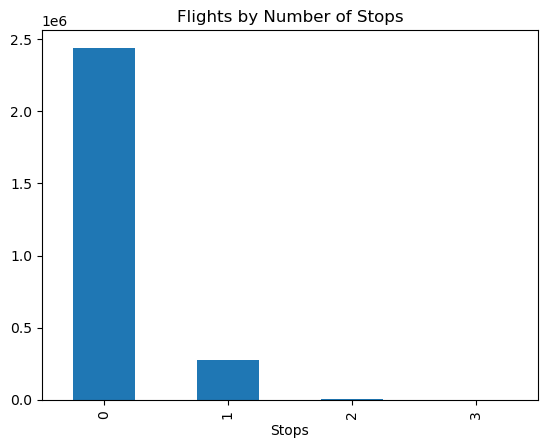

In [17]:
df.groupby('Stops')['All_Flights'].sum().plot(kind='bar')
plt.title('Flights by Number of Stops')
plt.show()

# 9. Time-Based Analysis

## Yearly Trend

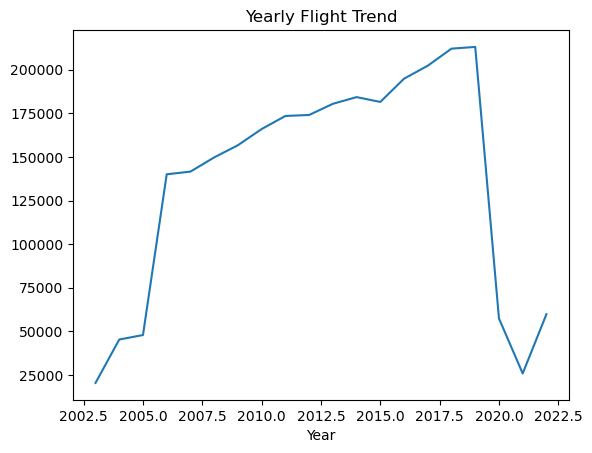

In [18]:
df.groupby('Year')['All_Flights'].sum().plot()
plt.title('Yearly Flight Trend')
plt.show()

## Monthly Trend

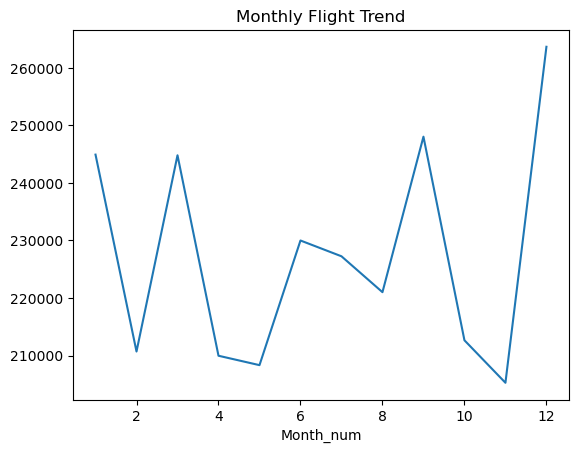

In [19]:
df.groupby('Month_num')['All_Flights'].sum().plot()
plt.title('Monthly Flight Trend')
plt.show()

# 10. Capacity Analysis

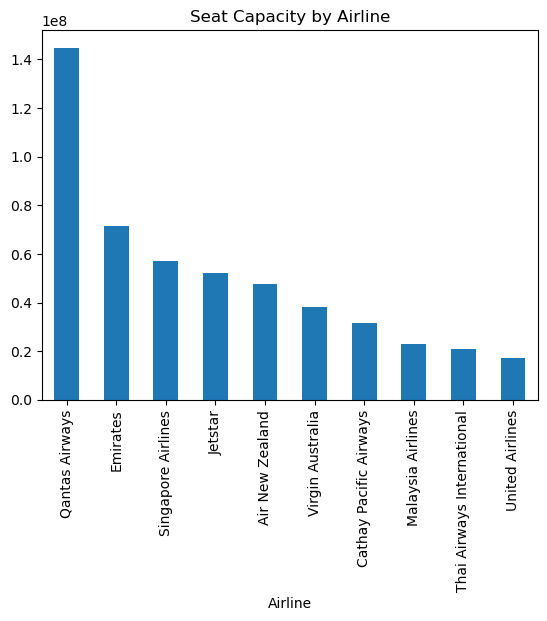

In [20]:
df.groupby('Airline')['Max_Seats'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Seat Capacity by Airline')
plt.show()

# 11. Flights vs Seats (Efficiency)

In [21]:
df['Load_Factor'] = df['All_Flights'] / df['Max_Seats']

df[['All_Flights', 'Max_Seats', 'Load_Factor']].corr()

,All_Flights,Max_Seats,Load_Factor
All_Flights,1.000000,0.902128,-0.049791
Max_Seats,0.902128,1.000000,-0.303523
Load_Factor,-0.049791,-0.303523,1.000000


# 12. Correlation Heatmap

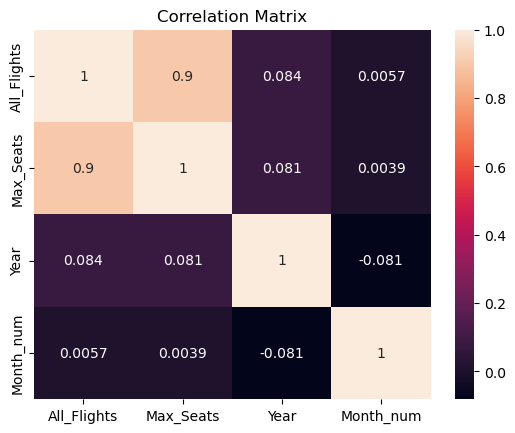

In [22]:
corr = df[['All_Flights', 'Max_Seats', 'Year', 'Month_num']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

# Connectivity with SQLDB

In [23]:
import sqlite3
from IPython.display import display

In [24]:
conn = sqlite3.connect("australian_flight.db")
df.to_sql("flights", conn, if_exists="replace", index=False)

110055

## SQL Queries

In [25]:
query = "SELECT * from flights"
result = pd.read_sql(query, conn)
display(result)

,_id,Month,In_Out,Australian_City,International_City,Airline,Route,Port_Country,Port_Region,Service_Country,Service_Region,Stops,All_Flights,Max_Seats,Year,Month_num,Load_Factor
0,1,Sep-03,I,Adelaide,Denpasar,Garuda Indonesia,DPS-ADL-MEL,Indonesia,SE Asia,Indonesia,SE Asia,0,13,3809,2003,9,0.003413
1,2,Sep-03,I,Adelaide,Hong Kong,Cathay Pacific Airways,HKG-ADL-MEL,Hong Kong (SAR),NE Asia,Hong Kong (SAR),NE Asia,0,8,2008,2003,9,0.003984
2,3,Sep-03,I,Adelaide,Kuala Lumpur,Malaysia Airlines,KUL-ADL,Malaysia,SE Asia,Malaysia,SE Asia,0,17,4726,2003,9,0.003597
3,4,Sep-03,I,Adelaide,Singapore,Qantas Airways,SIN-DRW-ADL-MEL,Singapore,SE Asia,Singapore,SE Asia,1,4,908,2003,9,0.004405
4,5,Sep-03,I,Adelaide,Singapore,Qantas Airways,SIN-DRW-ADL-SYD,Singapore,SE Asia,Singapore,SE Asia,1,9,2038,2003,9,0.004416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110050,110051,Sep-22,O,Sydney,Vancouver,Air Canada,SYD-YVR,Canada,N America,Canada,N America,0,33,10232,2022,9,0.003225
110051,110052,Sep-22,O,Sydney,Vancouver,Qantas Airways,SYD-YVR,Canada,N America,Canada,N America,0,13,3068,2022,9,0.004237
110052,110053,Sep-22,O,Sydney,Wellington,Air New Zealand,SYD-WLG,New Zealand,New Zealand,New Zealand,New Zealand,0,29,4686,2022,9,0.006189
110053,110054,Sep-22,O,Sydney,Wellington,Qantas Airways,SYD-WLG,New Zealand,New Zealand,New Zealand,New Zealand,0,42,7308,2022,9,0.005747


# Q1. Top 5 airlines with highest flights

In [28]:
query = """ 
           SELECT Airline, SUM(All_Flights) AS total_flights
            FROM flights
            GROUP BY Airline
            ORDER BY total_flights DESC
            LIMIT 5;
        """
result = pd.read_sql(query, conn)
display(result)

,Airline,total_flights
0,Qantas Airways,522252
1,Air New Zealand,237272
2,Jetstar,224210
3,Virgin Australia,199151
4,Emirates,186798


# Q2. Routes with highest traffic

In [29]:
query = """
            SELECT Route, SUM(All_Flights) AS total_flights
            FROM flights
            GROUP BY Route
            ORDER BY total_flights DESC;
        """
result = pd.read_sql(query,conn)
display(result)

,Route,total_flights
0,SYD-AKL,61743
1,AKL-SYD,61710
2,PER-SIN,38325
3,SIN-PER,38223
4,AKL-MEL,36513
...,...,...
1255,GUM-OOL,1
1256,DRW-SUB,1
1257,BUE-MEL,1
1258,BNE-TBU,1


# Q3. Month-wise flight variation

In [30]:
query = """
            SELECT Month, SUM(All_Flights) AS total_flights
            FROM flights
            GROUP BY Month
            ORDER BY MIN(Month_num);
        """
result = pd.read_sql(query,conn)
display(result)

,Month,total_flights
0,Jan-06,12444
1,Jan-07,12310
2,Jan-08,12684
3,Jan-09,13661
4,Jan-10,14478
...,...,...
206,Dec-17,18675
207,Dec-18,19142
208,Dec-19,19466
209,Dec-20,1723


# Q4. Domestic vs International flights

In [31]:
query = """
        SELECT In_Out, SUM(All_Flights) AS total_flights
        FROM flights
        GROUP BY In_Out;
        """
result = pd.read_sql(query,conn)
display(result)

,In_Out,total_flights
0,I,1362925
1,O,1363728


# Q5. Australian city with most flights

In [32]:
query = """
        SELECT Australian_City, SUM(All_Flights) AS total_flights
        FROM flights
        GROUP BY Australian_City
        ORDER BY total_flights DESC
        LIMIT 1; 
        """
result = pd.read_sql(query,conn)
display(result)

,Australian_City,total_flights
0,Sydney,1106422


# Q6. Airline with highest average seating capacity

query = """
        SELECT Airline, AVG(Max_Seats) AS avg_seats
        FROM flights
        GROUP BY Airline
        ORDER BY avg_seats DESC;
        """
result = pd.read_sql(query,conn)
display(result)

# Q7. Top destination countries

In [36]:
query = """
        SELECT Port_Country, SUM(All_Flights) AS total_flights
        FROM flights
        GROUP BY Port_Country
        ORDER BY total_flights DESC
        LIMIT 5;
        """
result = pd.read_sql(query,conn)
display(result)

,Port_Country,total_flights
0,New Zealand,645749
1,Singapore,363522
2,Indonesia,203355
3,USA,187450
4,Hong Kong (SAR),169726


# Q8. Routes with highest stops vs frequency

In [37]:
query = """
        SELECT Route, AVG(Stops) AS avg_stops, SUM(All_Flights) AS total_flights
        FROM flights
        GROUP BY Route
        ORDER BY avg_stops DESC, total_flights DESC;
        """
result = pd.read_sql(query,conn)
display(result)

,Route,avg_stops,total_flights
0,MEL-BNE-(HIR)-INU,2.0,12
1,INU-(HIR)-BNE-MEL,2.0,9
2,CHI-LAX-BNE-SYD-MEL,1.5,18
3,NYC-LAX-HNL-SYD-MEL,1.5,12
4,YVR-SFO-BNE-SYD-MEL,1.5,12
...,...,...,...
1255,OOL-GUM,0.0,1
1256,SCL-BNE,0.0,1
1257,SEL-OOL,0.0,1
1258,SHA-ADL,0.0,1


# Q9. Most efficient airlines (min stops, max flights)

In [38]:
query = """
        SELECT Airline, AVG(Stops) AS avg_stops, SUM(All_Flights) AS total_flights
        FROM flights
        GROUP BY Airline
        ORDER BY avg_stops ASC, total_flights DESC;
        """
result = pd.read_sql(query,conn)
display(result)

,Airline,avg_stops,total_flights
0,AirAsia X,0.000000,44306
1,Fiji Airways,0.000000,41129
2,Indonesia AirAsia,0.000000,27766
3,China Airlines,0.000000,22514
4,Royal Brunei Airlines,0.000000,16874
...,...,...,...
85,Gulf Air,0.500000,3064
86,Austrian Airlines,0.500000,2606
87,Hong Kong Airlines,0.500000,2026
88,Lauda Air,0.500000,1124
